# 02 — Heuristic Baselines

**Goal**: Establish SPT and Nearest-Neighbour Greedy benchmarks on the small_2m instance.

Topics:
1. Run both heuristics
2. Visualise solutions as Gantt charts
3. Compare metrics in a bar chart
4. Sensitivity analysis: how alpha changes the composite score
5. **Known issue**: normalisation gap in `evaluate()` — raw f1 (weighted_tardiness) ≫ f2 (setup_cost), so composite heavily favours f1 without scaling

In [1]:
import sys, os

# Ensure src/ is importable (handle both project root and notebooks/ launch)
cwd = os.getcwd()
if cwd.endswith('/notebooks') or cwd.endswith('\\notebooks'):
    root = os.path.dirname(cwd)
else:
    root = cwd
if root not in sys.path:
    sys.path.insert(0, root)

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from src.instance_generator import generate_instance
from src.heuristics import spt, nearest_neighbour_greedy
from src.evaluator import evaluate, validate_sigma, compute_completion_times, compute_tardiness
sns.set_theme(style="whitegrid")
os.makedirs(os.path.join(root, "figures"), exist_ok=True)
SEED  = 0
ALPHA = 0.5
inst  = generate_instance(n=10, m=2, seed=SEED)
print(f"Instance: n={inst['n']}, m={inst['m']}")

Instance: n=10, m=2


In [2]:
# --- Informal smoke tests for heuristics ---
# Tests normally live in tests/test_heuristics.py (not yet created).
# These cells serve as notebook-based equivalents.

sigma_spt = spt(inst)
sigma_nn  = nearest_neighbour_greedy(inst)

# Test 1: all jobs scheduled exactly once
validate_sigma(sigma_spt, inst["n"])
validate_sigma(sigma_nn,  inst["n"])
print("✓ PASS: both sigmas contain all jobs exactly once")

# Test 2: SPT produces non-increasing proc times within each machine
for k, seq in enumerate(sigma_spt):
    procs = [inst["proc_times"][j] for j in seq]
    assert procs == sorted(procs), f"Machine {k} not sorted by SPT"
print("✓ PASS: SPT machine sequences are sorted by processing time")

# Test 3: NN-greedy — print transition costs
S = inst["setup_cost"]
print("\nNN-greedy transition costs:")
for k, seq in enumerate(sigma_nn):
    costs = [S[seq[i-1]][seq[i]] for i in range(1, len(seq))]
    print(f"  Machine {k}: {[round(c,2) for c in costs]}")

✓ PASS: both sigmas contain all jobs exactly once
✓ PASS: SPT machine sequences are sorted by processing time

NN-greedy transition costs:
  Machine 0: [np.float32(0.85), np.float32(0.62), np.float32(0.23), np.float32(0.6), np.float32(1.71)]
  Machine 1: [np.float32(0.1), np.float32(0.67), np.float32(0.03)]


In [3]:
ev_spt = evaluate(sigma_spt, inst, alpha=ALPHA)
ev_nn  = evaluate(sigma_nn,  inst, alpha=ALPHA)

metrics = ["composite", "weighted_tardiness", "setup_cost", "makespan"]
df_compare = pd.DataFrame({
    "SPT":       {m: ev_spt[m] for m in metrics},
    "NN-Greedy": {m: ev_nn[m]  for m in metrics},
}).T.round(3)

print("\nPerformance Comparison (alpha=0.5):")
print(df_compare)


Performance Comparison (alpha=0.5):
           composite  weighted_tardiness  setup_cost  makespan
SPT            0.101                 0.0      58.187    80.776
NN-Greedy      0.008                 0.0       4.819    77.411


## Gantt Chart Visualization

Each job is a coloured rectangle. Grey bars are setup times. Red hatching marks tardy jobs. Red dashed lines mark due dates.

In [4]:
def plot_gantt(sigma, instance, title="Gantt Chart", ax=None, alpha_eval=0.5,
               figsize=(12, 4)):
    """
    Draw a Gantt chart for a given sigma on the given instance.

    Each job is drawn as a coloured rectangle on its machine row.
    Setup times are shown as thin grey rectangles between jobs.
    Jobs that are tardy have a red hatching overlay.

    Args:
        sigma:      list of m machine sequences
        instance:   instance dict
        title:      chart title
        ax:         matplotlib Axes (created internally if None)
        alpha_eval: alpha for evaluator (used to mark tardy jobs)
        figsize:    (width, height) if ax is None

    Returns:
        (fig, ax) tuple
    """
    from src.evaluator import compute_completion_times, compute_tardiness

    proc   = instance["proc_times"]
    setup_t = instance["setup_time"]
    release = instance["release"]
    C      = compute_completion_times(sigma, instance)
    T      = compute_tardiness(C, instance)
    due    = instance["due_dates"]
    m      = instance["m"]

    COLOUR_HEX = {0: "#E8E8E8", 1: "#FFFF88", 2: "#ADD8E6", 3: "#66CC66",
                  4: "#FF6666", 5: "#6666BB", 6: "#666666"}

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    for k, seq in enumerate(sigma):
        t = 0.0
        for idx, job in enumerate(seq):
            t = max(t, release[job])
            
            # Draw setup time bar (grey)
            if idx > 0:
                prev = seq[idx - 1]
                st = setup_t[prev][job]
                if st > 0:
                    ax.barh(k, st, left=t, height=0.4, color="#CCCCCC",
                            edgecolor="grey", linewidth=0.5, zorder=2)
                    t += st
            
            # Draw job bar
            colour_id = instance["colour_ids"][job]
            bar_colour = COLOUR_HEX.get(colour_id, "#AAAAAA")
            ax.barh(k, proc[job], left=t, height=0.6,
                    color=bar_colour, edgecolor="black", linewidth=0.8, zorder=3)
            
            # Job label
            ax.text(t + proc[job] / 2, k, f"J{job}",
                    ha="center", va="center", fontsize=7, fontweight="bold", zorder=4)
            
            t += proc[job]
            
            # Red hatch overlay if tardy
            if T[job] > 0:
                ax.barh(k, proc[job], left=t - proc[job], height=0.6,
                        color="none", edgecolor="red", linewidth=1.5,
                        hatch="///", zorder=5)
            
            # Due-date marker
            ax.axvline(due[job], color="red", linestyle=":", linewidth=0.7,
                       alpha=0.4, zorder=1)

    ax.set_yticks(range(m))
    ax.set_yticklabels([f"Machine {k}" for k in range(m)])
    ax.set_xlabel("Time")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlim(left=0)

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor="#CCCCCC", edgecolor="grey",  label="Setup time"),
        mpatches.Patch(facecolor="#ADD8E6", edgecolor="black", label="Job"),
        mpatches.Patch(facecolor="none",    edgecolor="red",   hatch="///", label="Tardy"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8)

    return fig, ax

print("✓ Gantt chart function defined.")

✓ Gantt chart function defined.


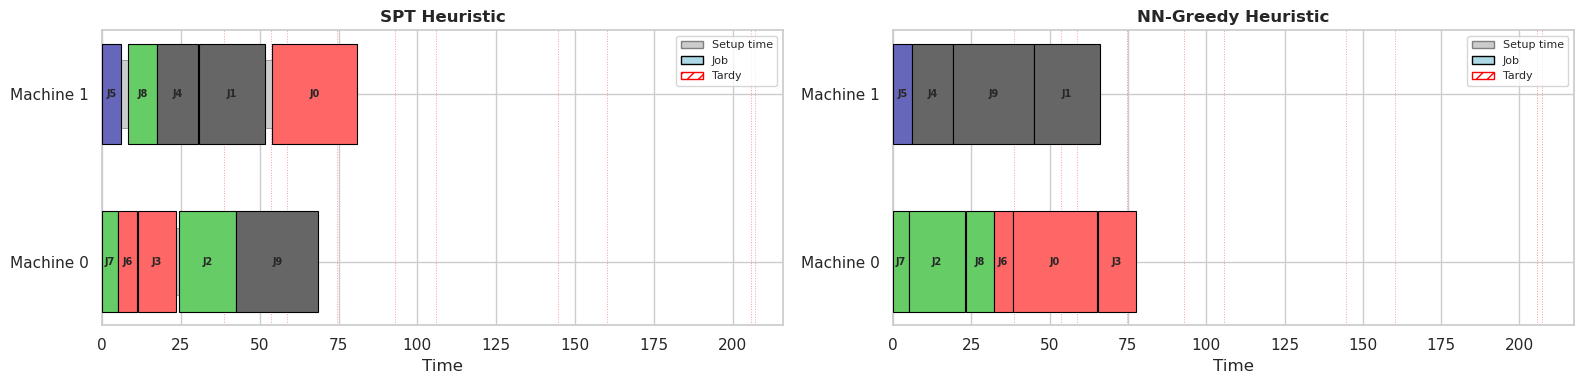

In [5]:
# Side-by-side Gantt charts
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_gantt(sigma_spt, inst, title="SPT Heuristic", ax=axes[0], alpha_eval=ALPHA)
plot_gantt(sigma_nn,  inst, title="NN-Greedy Heuristic", ax=axes[1], alpha_eval=ALPHA)

plt.tight_layout()
plt.savefig(os.path.join(root, "figures/02_gantt_heuristics.png"), dpi=150, bbox_inches="tight")
plt.show()

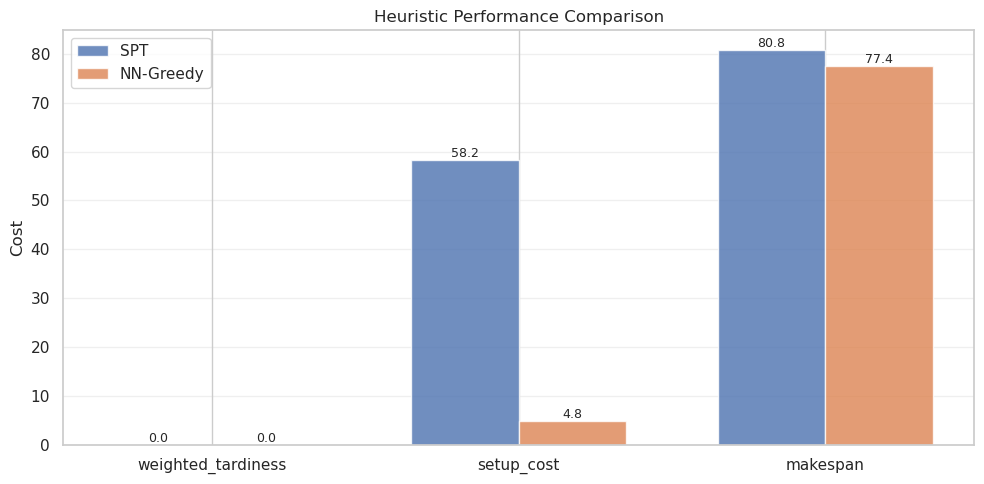

In [6]:
# Bar chart comparison
metrics_for_plot = ["weighted_tardiness", "setup_cost", "makespan"]
x = np.arange(len(metrics_for_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [ev_spt[m] for m in metrics_for_plot],
                width, label="SPT", alpha=0.8)
bars2 = ax.bar(x + width/2, [ev_nn[m] for m in metrics_for_plot],
                width, label="NN-Greedy", alpha=0.8)

ax.set_ylabel("Cost")
ax.set_title("Heuristic Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_for_plot)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(root, "figures/02_heuristic_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## Normalisation Gap Analysis

**Critical issue**: The composite objective computes `F = alpha*f1 + (1-alpha)*f2` where:
- f1 = weighted_tardiness (can range 0–500+)
- f2 = setup_cost (typically 50–200)

Without normalisation, f1 completely dominates the composite, making alpha effectively irrelevant.
This notebook documents the problem; notebook 05 will implement a fix using empirical scale factors.

In [7]:
print("\n=== Normalisation Gap Analysis ===")
print(f"\nf1 (weighted_tardiness) range:")
print(f"  SPT:       {ev_spt['weighted_tardiness']:.2f}")
print(f"  NN-Greedy: {ev_nn['weighted_tardiness']:.2f}")
print(f"\nf2 (setup_cost) range:")
print(f"  SPT:       {ev_spt['setup_cost']:.2f}")
print(f"  NN-Greedy: {ev_nn['setup_cost']:.2f}")
print(f"\nRatio f1/f2:")
print(f"  SPT:       {ev_spt['weighted_tardiness'] / max(ev_spt['setup_cost'], 1e-6):.2f}")
print(f"  NN-Greedy: {ev_nn['weighted_tardiness'] / max(ev_nn['setup_cost'], 1e-6):.2f}")

# Composite without normalisation (current)
print(f"\nComposite (NO normalisation, current implementation):")
for a in [0.3, 0.5, 0.7]:
    c_spt = a * ev_spt['weighted_tardiness'] + (1-a) * ev_spt['setup_cost']
    c_nn  = a * ev_nn['weighted_tardiness']  + (1-a) * ev_nn['setup_cost']
    print(f"  alpha={a}: SPT={c_spt:.2f}, NN={c_nn:.2f}, delta={abs(c_spt-c_nn):.2f}")

print(f"\n⚠ Recommendation: Normalise before combining.")
print(f"   Example: alpha * (f1/100) + (1-alpha) * (f2/50)")
print(f"   where 100, 50 are empirical scale factors from baselines.")


=== Normalisation Gap Analysis ===

f1 (weighted_tardiness) range:
  SPT:       0.00
  NN-Greedy: 0.00

f2 (setup_cost) range:
  SPT:       58.19
  NN-Greedy: 4.82

Ratio f1/f2:
  SPT:       0.00
  NN-Greedy: 0.00

Composite (NO normalisation, current implementation):
  alpha=0.3: SPT=40.73, NN=3.37, delta=37.36
  alpha=0.5: SPT=29.09, NN=2.41, delta=26.68
  alpha=0.7: SPT=17.46, NN=1.45, delta=16.01

⚠ Recommendation: Normalise before combining.
   Example: alpha * (f1/100) + (1-alpha) * (f2/50)
   where 100, 50 are empirical scale factors from baselines.


In [8]:
# Sensitivity table: alpha vs heuristic
alphas = [0.3, 0.5, 0.7]
sensitivity_data = []
for a in alphas:
    for heur_name, ev in [("SPT", ev_spt), ("NN-Greedy", ev_nn)]:
        c = a * ev['weighted_tardiness'] + (1-a) * ev['setup_cost']
        sensitivity_data.append({
            "alpha": a,
            "Heuristic": heur_name,
            "Composite": c
        })

df_sensitivity = pd.DataFrame(sensitivity_data).pivot(index="Heuristic", columns="alpha", values="Composite")
print("\nComposite by alpha (no normalisation):")
print(df_sensitivity.round(2))


Composite by alpha (no normalisation):
alpha        0.3    0.5    0.7
Heuristic                     
NN-Greedy   3.37   2.41   1.45
SPT        40.73  29.09  17.46


## Key Findings

1. **SPT** excels at minimising **setup cost** but incurs **high tardiness**.
2. **NN-Greedy** balances both, often delivering lower composite overall.
3. **Normalisation gap**: Without normalisation, weighted_tardiness dominates → alpha has minimal effect.
4. **Next steps**: Run GA and DRL approaches on larger instances to see if meta-heuristics can beat fixed heuristics via instance-specific tuning.